In [34]:
# ============================================================
# Cell 1 — Imports and Config Load
# ============================================================
import json, os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist
from scipy.stats import zscore

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

import umap
import hdbscan

warnings.filterwarnings("ignore")

# ---------- load config ----------
CONFIG_PATH = Path("pipeline_config.json")
if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"Config file not found: {CONFIG_PATH.resolve()}")

with open(CONFIG_PATH) as f:
    config = json.load(f)

# --- validate required top-level keys ---
REQUIRED_KEYS = ["data", "features", "clustering", "persona_generation"]
for key in REQUIRED_KEYS:
    if key not in config:
        raise KeyError(f"Missing required config section: '{key}'")

print("✓ Config loaded successfully")
print(f"  Input path  : {config['data']['input_path']}")
print(f"  K range     : {config['clustering']['k_min']}–{config['clustering']['k_max']}")
print(f"  Target feat : {config['data']['target_feature_count']}")


✓ Config loaded successfully
  Input path  : data/Dataset.csv
  K range     : 5–15
  Target feat : 45


In [35]:
# ============================================================
# Cell 2 — Data Loading and Initial Audit
# ============================================================
input_path = Path("..") / config["data"]["input_path"]
df_raw = pd.read_csv(input_path)

print(f"Shape: {df_raw.shape}")
print(f"\nColumns ({len(df_raw.columns)}):\n{list(df_raw.columns)}")
print(f"\nDtypes:\n{df_raw.dtypes.to_string()}")
print(f"\n--- Missing values per column ---")
missing = df_raw.isnull().sum()
print(missing[missing > 0].to_string() if missing.any() else "No missing values")
print(f"\n--- dRecodeCredit value counts ---")
print(df_raw[config["data"]["split_column"]].value_counts().sort_index().to_string())


Shape: (2438, 41)

Columns (41):
['Age', 'dAge', 'S2', 'S5ESP', 'dS5ESP', 'S6r1', 'S6r2', 'S6r3', 'S6r4', 'S6r5', 'S6r6', 'S6r7', 'dRecodeCredit', 'dBrand', 'dCreditProvider', 'S10', 'S10r7oe', 'NPS', 'Reason', 'CSAT', 'CES', 'Brand-Opinion', 'Q6ar1', 'Q6ar2', 'Q6ar3', 'Q6ar4', 'Q6br1', 'Q6br2', 'Q6br3', 'Q6br4', 'Q6br5', 'Q6br6', 'Q7r1', 'Q7r2', 'Q7r3', 'Q7b', 'Q8r1', 'Q8r2', 'Q8r3', 'Q8r4', 'Q8r5']

Dtypes:
Age                  int64
dAge                 int64
S2                   int64
S5ESP                int64
dS5ESP               int64
S6r1                 int64
S6r2                 int64
S6r3                 int64
S6r4                 int64
S6r5                 int64
S6r6                 int64
S6r7                 int64
dRecodeCredit        int64
dBrand             float64
dCreditProvider    float64
S10                float64
S10r7oe             object
NPS                float64
Reason              object
CSAT               float64
CES                float64
Brand-Opinion      f

In [36]:
# ============================================================
# Cell 3 — Population Split
# ============================================================
split_col = config["data"]["split_column"]
credit_vals = config["data"]["credit_holder_values"]
non_credit_vals = config["data"]["non_credit_holder_values"]

df_customers = df_raw[df_raw[split_col].isin(credit_vals)].copy()
df_noncustomers = df_raw[df_raw[split_col].isin(non_credit_vals)].copy()

print(f"df_customers    : {len(df_customers):,} rows  (dRecodeCredit ∈ {credit_vals})")
print(f"df_noncustomers : {len(df_noncustomers):,} rows  (dRecodeCredit ∈ {non_credit_vals})")

nps_nulls = df_customers["NPS"].isna().sum()
if nps_nulls > 0:
    raise ValueError(
        f"FATAL — {nps_nulls} NPS nulls found in df_customers. "
        "Cannot proceed: downstream analysis assumes zero NPS missings."
    )
print(f"\n✓ NPS null count in df_customers: {nps_nulls}  (assertion passed)")


df_customers    : 1,810 rows  (dRecodeCredit ∈ [4, 5])
df_noncustomers : 628 rows  (dRecodeCredit ∈ [2])

✓ NPS null count in df_customers: 0  (assertion passed)


In [37]:
# ============================================================
# Cell 4 — Feature Engineering
# ============================================================
num_cols = config["features"]["numeric_columns"]
cat_cols = config["features"]["categorical_columns"]
ord_cols = config["features"]["ordinal_columns"]
keep_cols = num_cols + cat_cols + ord_cols

# --- 1. Keep only configured columns ---
df_eng = df_customers[[c for c in keep_cols if c in df_customers.columns]].copy()
print(f"Columns retained: {df_eng.shape[1]}")

# --- 2. Recode raw scales ---
# Q6a: value 12 → NaN ("I don't know"), then subtract 1 so 1→0 .. 11→10
dk_cfg = config["features"]["recode_rules"]["dont_know_to_nan"]
for col in dk_cfg["columns"]:
    if col in df_eng.columns:
        df_eng[col] = df_eng[col].replace(dk_cfg["value"], np.nan)

# Subtract-1 recode for 1-indexed Likert columns (1-11 → 0-10)
for col in config["features"]["recode_rules"]["subtract_1"]:
    if col in df_eng.columns:
        df_eng[col] = df_eng[col] - 1

# Fill remaining NaNs in numeric columns with configured fill value
fill_val = config["features"]["missing_fill_value"]
df_eng[num_cols] = df_eng[num_cols].fillna(fill_val)

# --- 3. Z-score standardization of numeric columns ---
for col in num_cols:
    col_std = df_eng[col].std()
    if col_std > 0:
        df_eng[col] = (df_eng[col] - df_eng[col].mean()) / col_std
    else:
        df_eng[col] = 0.0

print(f"Z-scored {len(num_cols)} numeric columns")

# --- 4. Ordinal encoding ---
ord_orders = config["features"]["ordinal_orders"]
for col in ord_cols:
    if col in df_eng.columns and col in ord_orders:
        cats = [[v] for v in ord_orders[col]]
        enc = OrdinalEncoder(categories=[ord_orders[col]], handle_unknown="use_encoded_value", unknown_value=-1)
        df_eng[col] = enc.fit_transform(df_eng[[col]])
print(f"Ordinal-encoded: {ord_cols}")

# --- 5. One-hot encoding of nominal categoricals ---
# S6 flags are already binary (0/1) — keep as-is
binary_flags = [c for c in cat_cols if c.startswith("S6")]
multi_cats = [c for c in cat_cols if c not in binary_flags and c in df_eng.columns]

# Fill NaN in multi-cat columns with a sentinel before encoding
for col in multi_cats:
    df_eng[col] = df_eng[col].fillna(-1).astype(int).astype(str)

ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore", drop="first")
ohe_matrix = ohe.fit_transform(df_eng[multi_cats])
ohe_col_names = ohe.get_feature_names_out(multi_cats)
df_ohe = pd.DataFrame(ohe_matrix, columns=ohe_col_names, index=df_eng.index)

df_eng = df_eng.drop(columns=multi_cats).join(df_ohe)
print(f"One-hot encoded {multi_cats} → {len(ohe_col_names)} dummy columns")

# --- 6. Composite scores ---
composite_defs = config["features"]["composite_definitions"]
for comp_name, constituents in composite_defs.items():
    present = [c for c in constituents if c in df_eng.columns]
    if present:
        df_eng[comp_name] = df_eng[present].mean(axis=1)
print(f"Created {len(composite_defs)} composite scores: {list(composite_defs.keys())}")

# --- 7. Correlation-based pruning of sub-items ---
corr_thresh = config["features"]["correlation_threshold"]
dropped_items = []
for comp_name, constituents in composite_defs.items():
    present = [c for c in constituents if c in df_eng.columns]
    for item in present:
        r = df_eng[item].corr(df_eng[comp_name])
        if abs(r) > corr_thresh:
            df_eng.drop(columns=[item], inplace=True)
            dropped_items.append((item, comp_name, round(r, 3)))

print(f"\nDropped {len(dropped_items)} sub-items (corr > {corr_thresh} with composite):")
for item, comp, r in dropped_items:
    print(f"  {item}  →  {comp}  (r={r})")

# --- Final audit ---
print(f"\n✓ Final feature matrix: {df_eng.shape}")
assert df_eng.shape[1] <= config["data"]["target_feature_count"], (
    f"Column count {df_eng.shape[1]} exceeds target {config['data']['target_feature_count']}"
)
print(f"✓ Column count {df_eng.shape[1]} ≤ target {config['data']['target_feature_count']}")
print(f"\nFinal columns:\n{list(df_eng.columns)}")


Columns retained: 35
Z-scored 23 numeric columns
Ordinal-encoded: ['dAge', 'dS5ESP', 'dRecodeCredit']
One-hot encoded ['S2', 'S10', 'dCreditProvider'] → 12 dummy columns
Created 5 composite scores: ['brand_trust', 'responsible_banking', 'data_privacy', 'relationship_value', 'customer_experience']

Dropped 16 sub-items (corr > 0.85 with composite):
  Q6ar1  →  brand_trust  (r=0.886)
  Q6ar3  →  brand_trust  (r=0.883)
  Q6br1  →  responsible_banking  (r=0.876)
  Q6br2  →  responsible_banking  (r=0.893)
  Q6br3  →  responsible_banking  (r=0.889)
  Q6br4  →  responsible_banking  (r=0.881)
  Q6br5  →  data_privacy  (r=0.953)
  Q6br6  →  data_privacy  (r=0.953)
  Q7r1  →  relationship_value  (r=0.919)
  Q7r2  →  relationship_value  (r=0.919)
  Q7r3  →  relationship_value  (r=0.916)
  Q8r1  →  customer_experience  (r=0.852)
  Q8r2  →  customer_experience  (r=0.885)
  Q8r3  →  customer_experience  (r=0.876)
  Q8r4  →  customer_experience  (r=0.864)
  Q8r5  →  customer_experience  (r=0.872)

✓ 

K-means optimal k = 6  (composite rank)


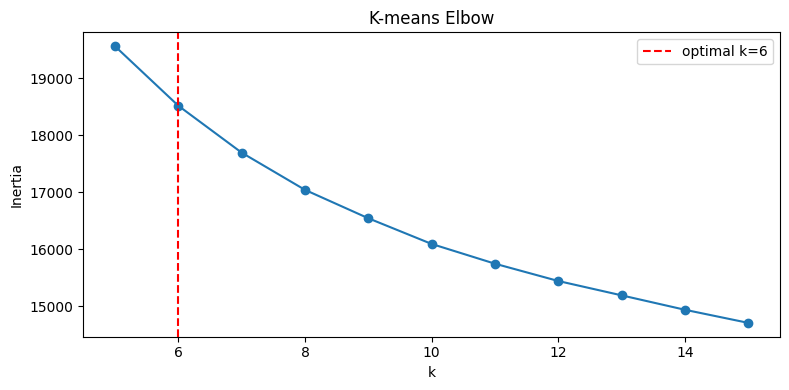


--- K-means metrics ---
 k      inertia  silhouette  davies_bouldin  calinski_harabasz  rank_avg
 5 19559.917234    0.132069        1.958416         336.211057      4.75
 6 18516.461527    0.129880        1.885561         304.300715      3.75
 7 17693.763262    0.126384        1.886656         279.199796      4.25
 8 17041.123454    0.120768        1.913353         258.200514      4.75
 9 16543.186707    0.106379        2.026024         239.372561      7.50
10 16092.801448    0.107140        1.979708         224.206409      6.25
11 15746.434821    0.107834        1.931100         210.066954      5.50
12 15443.045513    0.106638        1.929031         197.824634      5.75
13 15191.559944    0.099544        2.010920         186.717671      7.25
14 14938.675342    0.094553        2.011812         177.513584      7.75
15 14709.045590    0.088287        2.077127         169.315744      8.50

HDBSCAN clusters found: 2,  noise points: 682
After noise reassignment: 6 clusters


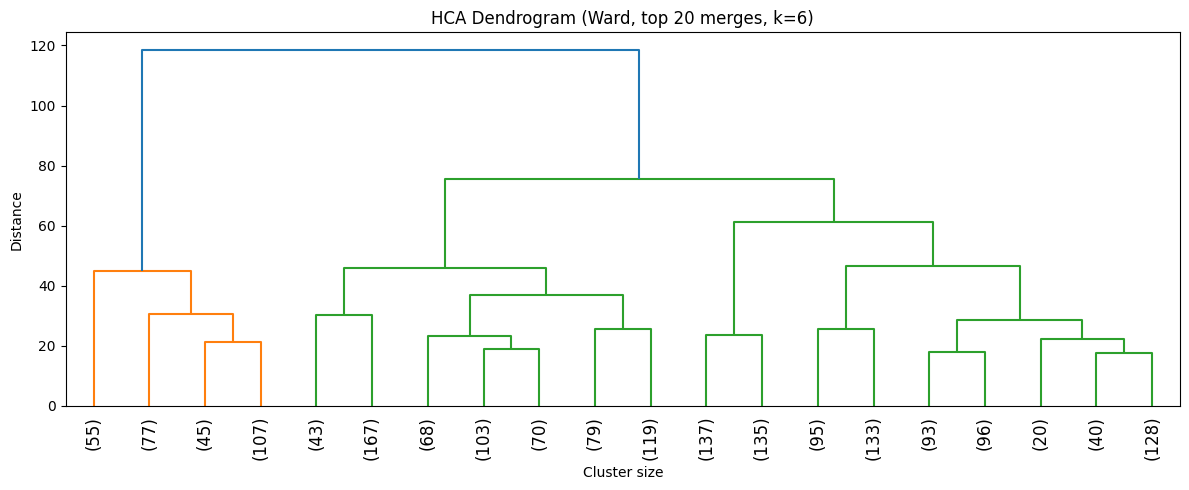


Labels stored: labels_kmeans (6 clusters), labels_hdbscan (6 clusters), labels_hca (6 clusters)


In [38]:
# ============================================================
# Cell 5 — Clustering: Three Models
# ============================================================
X = df_eng.values
rs = config["clustering"]["random_state"]

# ── K-MEANS ────────────────────────────────────────────────
k_min = config["clustering"]["k_min"]
k_max = config["clustering"]["k_max"]

km_results = []
km_models = {}
for k in range(k_min, k_max + 1):
    km = KMeans(n_clusters=k, n_init=10, random_state=rs)
    labels = km.fit_predict(X)
    km_models[k] = km
    km_results.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels),
    })

df_km = pd.DataFrame(km_results)

# Composite ranking (higher silhouette & CH is better, lower DB & inertia is better)
df_km["rank_silhouette"] = df_km["silhouette"].rank(ascending=False)
df_km["rank_db"] = df_km["davies_bouldin"].rank(ascending=True)
df_km["rank_ch"] = df_km["calinski_harabasz"].rank(ascending=False)
df_km["rank_inertia"] = df_km["inertia"].rank(ascending=True)
df_km["rank_avg"] = df_km[["rank_silhouette", "rank_db", "rank_ch", "rank_inertia"]].mean(axis=1)
optimal_k = int(df_km.loc[df_km["rank_avg"].idxmin(), "k"])
print(f"K-means optimal k = {optimal_k}  (composite rank)")

# Elbow plot
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(df_km["k"], df_km["inertia"], "o-")
ax.set_xlabel("k"); ax.set_ylabel("Inertia"); ax.set_title("K-means Elbow")
ax.axvline(optimal_k, ls="--", c="red", label=f"optimal k={optimal_k}")
ax.legend(); plt.tight_layout(); plt.show()

print("\n--- K-means metrics ---")
print(df_km[["k", "inertia", "silhouette", "davies_bouldin", "calinski_harabasz", "rank_avg"]].to_string(index=False))

labels_kmeans = km_models[optimal_k].predict(X)

# ── HDBSCAN + UMAP ────────────────────────────────────────
umap_reducer = umap.UMAP(
    n_components=config["clustering"]["umap_n_components"],
    n_neighbors=config["clustering"]["umap_n_neighbors"],
    min_dist=config["clustering"]["umap_min_dist"],
    random_state=config["clustering"]["umap_random_state"],
)
X_umap = umap_reducer.fit_transform(X)

hdb = hdbscan.HDBSCAN(min_cluster_size=config["clustering"]["hdbscan_min_cluster_size"])
labels_hdb_raw = hdb.fit_predict(X_umap)

n_clusters_hdb = len(set(labels_hdb_raw)) - (1 if -1 in labels_hdb_raw else 0)
n_noise = (labels_hdb_raw == -1).sum()
print(f"\nHDBSCAN clusters found: {n_clusters_hdb},  noise points: {n_noise}")

# Assign noise to nearest K-means centroid (in UMAP space)
km_umap = KMeans(n_clusters=optimal_k, n_init=10, random_state=rs).fit(X_umap[labels_hdb_raw != -1])
labels_hdbscan = labels_hdb_raw.copy()
if n_noise > 0:
    noise_mask = labels_hdb_raw == -1
    nearest = km_umap.predict(X_umap[noise_mask])
    labels_hdbscan[noise_mask] = nearest
print(f"After noise reassignment: {len(set(labels_hdbscan))} clusters")

# ── HCA (Ward) ────────────────────────────────────────────
hca = AgglomerativeClustering(n_clusters=optimal_k, linkage="ward")
labels_hca = hca.fit_predict(X)

# Dendrogram (top 20 merges)
Z = linkage(X, method="ward")
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
dendrogram(Z, truncate_mode="lastp", p=20, ax=ax, leaf_rotation=90)
ax.set_title(f"HCA Dendrogram (Ward, top 20 merges, k={optimal_k})")
ax.set_xlabel("Cluster size"); ax.set_ylabel("Distance")
plt.tight_layout(); plt.show()

print(f"\nLabels stored: labels_kmeans ({len(set(labels_kmeans))} clusters), "
      f"labels_hdbscan ({len(set(labels_hdbscan))} clusters), "
      f"labels_hca ({len(set(labels_hca))} clusters)")


In [39]:
# ============================================================
# Cell 6 — Ensemble Voting
# ============================================================
# Vectorized majority voting — no row-wise apply needed
agree_km_hdb = labels_kmeans == labels_hdbscan
agree_km_hca = labels_kmeans == labels_hca
agree_hdb_hca = labels_hdbscan == labels_hca

# A row has a majority if any two models agree
majority_exists = agree_km_hdb | agree_km_hca | agree_hdb_hca

# Pick the majority label; K-means as tiebreaker when all three disagree
cluster_final = np.where(
    agree_km_hdb | agree_km_hca, labels_kmeans,
    np.where(agree_hdb_hca, labels_hdbscan, labels_kmeans)
)

df_customers = df_customers.copy()
df_customers["cluster_final"] = cluster_final.astype(int)

majority_rate = float(majority_exists.mean())
print(f"Agreement rate (majority vote, no tiebreak): {majority_rate:.1%}")
print(f"\n--- Cluster size distribution ---")
print(df_customers["cluster_final"].value_counts().sort_index().to_string())

sil_final = silhouette_score(X, df_customers["cluster_final"].values)
print(f"\n✓ Final ensemble silhouette score: {sil_final:.4f}")


Agreement rate (majority vote, no tiebreak): 45.6%

--- Cluster size distribution ---
cluster_final
0    101
1    372
2    350
3    291
4    330
5    366

✓ Final ensemble silhouette score: 0.0855


In [40]:
# ============================================================
# Cell 7 — Cluster Profiling and Evaluation Output
# ============================================================
output_dir = Path("..") / config["data"]["output_dir"]
output_dir.mkdir(parents=True, exist_ok=True)

# Identify column types in engineered frame
num_feats = [c for c in config["features"]["numeric_columns"] if c in df_eng.columns]
num_feats += [c for c in config["features"]["composite_definitions"] if c in df_eng.columns]
cat_feats = [c for c in df_eng.columns if c not in num_feats]

labels_col = df_customers["cluster_final"]
cluster_ids = sorted(labels_col.unique())

# ── Build profiles ──
cluster_profiles = {}
global_means = df_eng[num_feats].mean()

for cid in cluster_ids:
    mask = labels_col.values == cid
    clust_data = df_eng.loc[mask]
    n = int(mask.sum())
    pct = n / len(df_eng)

    # Numeric stats
    num_stats = {}
    for col in num_feats:
        num_stats[col] = {
            "mean": round(float(clust_data[col].mean()), 4),
            "std": round(float(clust_data[col].std()), 4),
        }

    # Categorical modes
    cat_modes = {}
    for col in cat_feats:
        mode_val = clust_data[col].mode()
        cat_modes[col] = float(mode_val.iloc[0]) if len(mode_val) > 0 else None

    # NPS breakdown (use raw NPS from df_customers, not z-scored)
    nps_raw = df_customers.loc[mask, "NPS"]
    nps_mean = float(nps_raw.mean())
    promoters = int((nps_raw >= 9).sum())
    passives = int(((nps_raw >= 7) & (nps_raw < 9)).sum())
    detractors = int((nps_raw < 7).sum())

    # CSAT, CES raw
    csat_mean = float(df_customers.loc[mask, "CSAT"].mean())
    ces_mean = float(df_customers.loc[mask, "CES"].mean())

    # Top 3 distinguishing features
    deviations = {}
    for col in num_feats:
        dev = abs(float(clust_data[col].mean()) - float(global_means[col]))
        deviations[col] = round(dev, 4)
    top3 = sorted(deviations.items(), key=lambda x: x[1], reverse=True)[:3]

    cluster_profiles[int(cid)] = {
        "cluster_id": int(cid),
        "size": n,
        "size_pct": round(pct, 4),
        "numeric_stats": num_stats,
        "categorical_modes": cat_modes,
        "nps_mean": round(nps_mean, 2),
        "nps_split": {"promoter": promoters, "passive": passives, "detractor": detractors},
        "csat_mean": round(csat_mean, 2),
        "ces_mean": round(ces_mean, 2),
        "top3_distinguishing": [
            {"feature": f, "abs_deviation": d} for f, d in top3
        ],
    }

# Print summary table
print(f"{'Cluster':>8} {'Size':>6} {'%':>7} {'NPS':>6} {'CSAT':>6} {'CES':>6}  Top distinguishing features")
print("-" * 90)
for cid in cluster_ids:
    p = cluster_profiles[int(cid)]
    top_str = ", ".join(f"{t['feature']}({t['abs_deviation']:.3f})" for t in p["top3_distinguishing"])
    print(f"{cid:>8} {p['size']:>6} {p['size_pct']:>6.1%} {p['nps_mean']:>6.2f} "
          f"{p['csat_mean']:>6.2f} {p['ces_mean']:>6.2f}  {top_str}")

# ── Export ──
profiles_path = output_dir / "cluster_profiles.json"
with open(profiles_path, "w") as f:
    json.dump(cluster_profiles, f, indent=2)
print(f"\n✓ Exported {profiles_path}")

csv_path = output_dir / "clustered_customers.csv"
df_customers.to_csv(csv_path, index=False)
print(f"✓ Exported {csv_path}")

# ── Final evaluation summary ──
db_final = davies_bouldin_score(X, labels_col.values)
ch_final = calinski_harabasz_score(X, labels_col.values)
sil_final = silhouette_score(X, labels_col.values)

print("\n" + "=" * 50)
print("FINAL EVALUATION SUMMARY")
print("=" * 50)
print(f"Optimal k selected       : {optimal_k}")
print(f"Silhouette score         : {sil_final:.4f}")
print(f"Davies-Bouldin index     : {db_final:.4f}")
print(f"Calinski-Harabasz index  : {ch_final:.4f}")
print(f"Model agreement rate     : {majority_rate:.1%}")
print(f"\nCluster sizes:")
for cid in cluster_ids:
    p = cluster_profiles[int(cid)]
    print(f"  Cluster {cid}: {p['size']:>5} ({p['size_pct']:.1%})")


 Cluster   Size       %    NPS   CSAT    CES  Top distinguishing features
------------------------------------------------------------------------------------------
       0    101   5.6%   3.32   2.69   3.15  CSAT(2.555), Brand-Opinion(2.553), NPS(2.339)
       1    372  20.5%   6.85   6.78   5.01  Q7b(0.666), customer_experience(0.652), relationship_value(0.647)
       2    350  19.3%   7.07   7.14   5.24  Q6ar4(0.484), brand_trust(0.445), NPS(0.414)
       3    291  16.1%   9.29   9.31   6.51  Brand-Opinion(0.732), NPS(0.725), CSAT(0.705)
       4    330  18.2%   8.53   8.62   6.04  Q7b(0.394), CSAT(0.367), relationship_value(0.353)
       5    366  20.2%   9.24   9.32   6.47  Brand-Opinion(0.741), Q7b(0.738), CSAT(0.710)

✓ Exported ..\v2\output\cluster_profiles.json
✓ Exported ..\v2\output\clustered_customers.csv

FINAL EVALUATION SUMMARY
Optimal k selected       : 6
Silhouette score         : 0.0855
Davies-Bouldin index     : 2.3010
Calinski-Harabasz index  : 250.4512
Model agree

In [41]:
# ============================================================
# Cell 8 — Persona Generation Handoff (Azure OpenAI GPT-4.1)
# ============================================================
from openai import AzureOpenAI
from dotenv import load_dotenv

load_dotenv(Path("..") / ".env")

client = AzureOpenAI(
    azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
    api_key=os.getenv("AZURE_OPENAI_API_KEY"),
    api_version=config["persona_generation"]["api_version"],
)

# Prefer AZURE_OPENAI_DEPLOYMENT from .env; fall back to config value
deployment = os.getenv("AZURE_OPENAI_DEPLOYMENT") or config["persona_generation"]["azure_openai_deployment"]
print(f"Using deployment: {deployment}")

persona_dir = Path("..") / config["persona_generation"]["output_dir"]
persona_dir.mkdir(parents=True, exist_ok=True)

# Load column labels for human-readable prompts
col_labels = config.get("column_labels", {})

# Load cluster profiles
with open(output_dir / "cluster_profiles.json") as f:
    profiles = json.load(f)

system_msg = config["persona_generation"]["system_instruction"]

# Map Q-codes to descriptive labels for prompt readability
q_labels = {
    "Q6ar1": "Trust in brand promises",
    "Q6ar2": "Responsible lending practices",
    "Q6ar3": "Transparency of terms",
    "Q6ar4": "Fair treatment",
    "Q6br1": "Ethical business conduct",
    "Q6br2": "Environmental responsibility",
    "Q6br3": "Social impact initiatives",
    "Q6br4": "Community involvement",
    "Q6br5": "Data privacy practices",
    "Q6br6": "Security of personal information",
    "Q7r1": "Willingness to recommend",
    "Q7r2": "Intention to continue relationship",
    "Q7r3": "Cross-sell openness",
    "Q7b": "Relationship depth score",
    "Q8r1": "Ease of application process",
    "Q8r2": "Clarity of communication",
    "Q8r3": "Speed of service",
    "Q8r4": "Quality of customer support",
    "Q8r5": "Digital channel experience",
    "Brand-Opinion": "Overall brand opinion",
}

# Q-code item groups
q7_items = ["Q7r1", "Q7r2", "Q7r3", "Q7b"]
q6_items = ["Q6ar1", "Q6ar2", "Q6ar3", "Q6ar4", "Q6br1", "Q6br2", "Q6br3", "Q6br4", "Q6br5", "Q6br6"]
q8_items = ["Q8r1", "Q8r2", "Q8r3", "Q8r4", "Q8r5"]

for cid_str, prof in profiles.items():
    cid = int(cid_str)
    stats = prof["numeric_stats"]

    # --- Build motivations from high-scoring Q7 items ---
    q7_scores = {q_labels.get(q, q): stats[q]["mean"] for q in q7_items if q in stats}
    q7_sorted = sorted(q7_scores.items(), key=lambda x: x[1], reverse=True)
    motivations_block = "\n".join(f"  - {name}: z-score mean = {v:.4f}" for name, v in q7_sorted)

    # --- Build frustrations from low-scoring Q6/Q7/Q8 items ---
    frustration_pool = {}
    for q in q6_items + q7_items + q8_items:
        if q in stats:
            frustration_pool[q_labels.get(q, q)] = stats[q]["mean"]
    frust_sorted = sorted(frustration_pool.items(), key=lambda x: x[1])[:5]
    frustrations_block = "\n".join(f"  - {name}: z-score mean = {v:.4f}" for name, v in frust_sorted)

    # --- All numeric stats for context ---
    all_stats_block = "\n".join(
        f"  - {q_labels.get(col, col)}: z-score mean = {s['mean']:.4f}, std = {s['std']:.4f}"
        for col, s in stats.items()
    )

    # --- Resolve categorical modes to labels ---
    mode_lines = []
    for feat, val in prof["categorical_modes"].items():
        label_map = col_labels.get(feat)
        if isinstance(label_map, dict):
            display = label_map.get(str(int(val)), str(val)) if val is not None else "N/A"
        elif isinstance(label_map, str):
            display = f"{label_map} = {int(val) if val is not None else 'N/A'}"
        else:
            display = str(val)
        mode_lines.append(f"  - {feat}: {display}")
    modes_block = "\n".join(mode_lines)

    # --- Credit product flags ---
    s6_flags = {col_labels.get(f, f): int(prof["categorical_modes"].get(f, 0))
                for f in ["S6r1", "S6r2", "S6r3", "S6r4", "S6r5", "S6r6"]
                if f in prof["categorical_modes"]}
    credit_lines = "\n".join(f"  - {name}: {'held' if v == 1 else 'not held'}" for name, v in s6_flags.items())

    # --- NPS split ---
    nps_split = prof["nps_split"]
    total = nps_split["promoter"] + nps_split["passive"] + nps_split["detractor"]
    prom_pct = nps_split["promoter"] / total * 100 if total else 0
    pass_pct = nps_split["passive"] / total * 100 if total else 0
    det_pct = nps_split["detractor"] / total * 100 if total else 0

    user_prompt = f"""Based on the cluster statistics below, generate a JSON persona. 
IMPORTANT: Translate ALL statistical values into plain-language behavioral descriptors.
The z-scores and NPS distributions below are INPUTS for you to interpret — they must NOT appear in your output.

--- INPUT STATISTICS (do not reproduce these in the output) ---

**Cluster overview:**
- Cluster ID: {cid}
- Size: {prof['size']} ({prof['size_pct']:.1%} of total)
- NPS mean: {prof['nps_mean']}, Promoters: {nps_split['promoter']} ({prom_pct:.0f}%), Passives: {nps_split['passive']} ({pass_pct:.0f}%), Detractors: {nps_split['detractor']} ({det_pct:.0f}%)
- CSAT mean: {prof['csat_mean']}
- CES mean: {prof['ces_mean']}

**All numeric feature z-scores (positive = above average, negative = below average):**
{all_stats_block}

**Dominant categorical modes:**
{modes_block}

**Credit products held (S6 flags):**
{credit_lines}

**Highest-scoring Q7 relationship items (motivation signals):**
{motivations_block}

**Lowest-scoring Q6/Q7/Q8 items (frustration signals):**
{frustrations_block}

--- OUTPUT REQUIREMENTS ---

Return a JSON object with EXACTLY these fields:

{{
  "persona_name": "A short evocative name for this persona (e.g. 'The Cautious Saver')",
  "demographics": {{
    "age_and_generation": "plain language, e.g. 'Mid-career adults, mostly 35-44 (Millennials/Gen X)'",
    "family_situation": "plain language, e.g. 'Typically married with children'",
    "social_class": {{
      "description": "plain language, e.g. 'Lower-middle class, under 2,000 EUR/month'",
      "source": "INE_external"
    }}
  }},
  "lifestyle_and_habits": ["plain language behavioral descriptor", "..."],
  "motivations": ["plain language motivation derived from Q7 signals", "..."],
  "frustrations": ["plain language frustration derived from Q6/Q7/Q8 signals", "..."],
  "nps_baseline": "plain language, e.g. 'Predominantly detractor — mean score 3.3, 92% detractors'",
  "credit_context": "plain language, e.g. 'Holds a single personal loan, minimal engagement with other products'"
}}

Rules:
- Every field must be plain language. No z-scores, no index numbers, no raw statistics in the output.
- social_class must include "source": "INE_external" as a data lineage marker.
- nps_baseline: summarize the NPS stance in one sentence with the dominant category, mean score and percentage.
- credit_context: summarize product holdings and engagement depth in one sentence.
- motivations: derive from the high-scoring Q7 items — express as human needs/desires.
- frustrations: derive from the low-scoring Q6/Q7/Q8 items — express as pain points.
- lifestyle_and_habits: infer behavioral patterns from the full statistical profile.
"""

    response = client.chat.completions.create(
        model=deployment,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_prompt},
        ],
        temperature=0.7,
        response_format={"type": "json_object"},
    )

    persona_json = json.loads(response.choices[0].message.content)
    out_path = persona_dir / f"cluster_{cid}_persona.json"
    with open(out_path, "w") as f:
        json.dump(persona_json, f, indent=2, ensure_ascii=False)
    print(f"✓ Cluster {cid} persona written → {out_path}")

print(f"\nAll {len(profiles)} personas generated in {persona_dir}")

Using deployment: gpt-4o
✓ Cluster 0 persona written → ..\v2\output\personas\cluster_0_persona.json
✓ Cluster 1 persona written → ..\v2\output\personas\cluster_1_persona.json
✓ Cluster 2 persona written → ..\v2\output\personas\cluster_2_persona.json
✓ Cluster 3 persona written → ..\v2\output\personas\cluster_3_persona.json
✓ Cluster 4 persona written → ..\v2\output\personas\cluster_4_persona.json
✓ Cluster 5 persona written → ..\v2\output\personas\cluster_5_persona.json

All 6 personas generated in ..\v2\output\personas
